## 1. Problem ##

- Data for loans from 2007 to 2017Q3 from Lending Club in Kaggle.
- The goal is to predict the probability that a loan will default.
- Label 'charged_off' (a debt that a creditor has given up trying to collect on after a borrower has missed payments for several months) : Processing from loan_status variable. 
- 'charged_off: 1 means charge off and 0 means otherwise. This is also unbalanced dataset

**=> Problem to be solved: A binary classifier with unbalanced dataset**



## 2. Loading packages and data ##

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [2]:
# Load data
dataset = pd.read_csv('../input/lending-club/accepted_2007_to_2018Q4.csv.gz',\
                      compression='gzip', encoding='utf-8') 

/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3552: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [3]:
dataset.shape

(2260701, 151)

In [4]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
dataset.head(2)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,0.0,4421.723917,4421.72,3600.0,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,0.0,25679.660000,25679.66,24700.0,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [5]:
# backup data
loans = dataset

## 3. Data Preparation ##

### 3.1. Label check ###

In [6]:
dataset['loan_status'].value_counts()

Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: loan_status, dtype: int64

**Just care about Fully Paid and Charged Off status**

In [7]:
dataset = dataset.loc[dataset['loan_status'].isin(['Fully Paid', 'Charged Off'])]

In [8]:
dataset['loan_status'].value_counts(normalize=True, dropna=False)

Fully Paid     0.800374
Charged Off    0.199626
Name: loan_status, dtype: float64

**We have unbalanced dataset**

In [9]:
# Create new binary column: Full Paid as 0 and Charged Off as 1
dataset['charged_off'] = (dataset['loan_status'] == 'Charged Off').apply(np.uint8)
dataset.drop('loan_status', axis=1, inplace=True)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [10]:
dataset['charged_off'].value_counts(normalize=True, dropna=False)

0    0.800374
1    0.199626
Name: charged_off, dtype: float64

### 3.2. Feature Selection ###

There are 150 features. The elimination features selection steps are:
- '>'30% of missing values
- subjective judgement
- low correlation with label

### Missing values ###

In [11]:
# Sorted the number of missing values of features
missing_fractions = dataset.isnull().mean().round(3).sort_values(ascending=False)
missing_fractions

member_id                                     1.000
next_pymnt_d                                  1.000
orig_projected_additional_accrued_interest    0.997
hardship_loan_status                          0.996
hardship_length                               0.996
hardship_dpd                                  0.996
hardship_payoff_balance_amount                0.996
hardship_last_payment_amount                  0.996
hardship_end_date                             0.996
hardship_start_date                           0.996
payment_plan_start_date                       0.996
hardship_amount                               0.996
deferral_term                                 0.996
hardship_status                               0.996
hardship_reason                               0.996
hardship_type                                 0.996
sec_app_mths_since_last_major_derog           0.995
sec_app_chargeoff_within_12_mths              0.986
sec_app_num_rev_accts                         0.986
revol_bal_jo

In [12]:
# Take drop feature list with >30% of missing values
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print('Drop_list len:',len(drop_list))
print(drop_list)

Drop_list len: 58
['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_

In [13]:
# Drop feature list with >30% of missing values
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(1345310, 93)

In [14]:
print(sorted(dataset.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'charged_off', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sa

### Based on intutiveness ###

In [15]:
keep_list = ['charged_off','funded_amnt','addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code','last_pymnt_amnt','num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',"bc_util","bc_open_to_buy","avg_cur_bal","acc_open_past_24mths" ]
len(keep_list)

40

In [16]:
drop_list = [col for col in dataset.columns if col not in keep_list]

In [17]:
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(1345310, 39)

### Correlations ###

Drop features with < 0.03 in corr with label.

In [18]:
correlations = dataset.corr()

In [19]:
corr_charged_off = abs(correlations['charged_off']).sort_values(ascending=False)
corr_charged_off

charged_off              1.000000
last_pymnt_amnt          0.347385
int_rate                 0.258792
fico_range_low           0.130683
fico_range_high          0.130682
acc_open_past_24mths     0.099869
dti                      0.084510
bc_open_to_buy           0.082044
avg_cur_bal              0.078924
mort_acc                 0.075294
num_actv_rev_tl          0.070814
bc_util                  0.066152
funded_amnt              0.065658
loan_amnt                0.065604
revol_util               0.060048
mo_sin_rcnt_rev_tl_op    0.053937
installment              0.051701
mo_sin_old_rev_tl_op     0.050502
annual_inc               0.041759
open_acc                 0.028078
pub_rec                  0.026194
pub_rec_bankruptcies     0.025308
revol_bal                0.020010
total_acc                0.011300
Name: charged_off, dtype: float64

In [20]:
drop_list = sorted(list(corr_charged_off[corr_charged_off < 0.03].index))
drop_list

['open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'total_acc']

In [21]:
# Drop feature with less then 0.03 in corr. with labels
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(1345310, 34)

## 4. Exploratory analysis ##

In [22]:
dataset.describe(include='all')

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,purpose,title,zip_code,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,revol_util,initial_list_status,last_pymnt_amnt,application_type,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off
count,1345310.0,1.345310e+06,1.345310e+06,1345310,1.345310e+06,1.345310e+06,1345310,1345310,1259525,1266799,1345310,1.345310e+06,1345310,1345310,1328651,1345309,1345310,1.344936e+06,1345310,1.345310e+06,1.345310e+06,1.344453e+06,1345310,1.345310e+06,1345310,1.298029e+06,1.277761e+06,1.284167e+06,1.283398e+06,1.277782e+06,1.277782e+06,1.298029e+06,1.277783e+06,1.345310e+06
unique,1345310.0,NaN,NaN,2,NaN,NaN,7,35,378353,11,6,NaN,3,14,61682,943,51,NaN,739,NaN,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,68407277.0,NaN,NaN,36 months,NaN,NaN,B,C1,Teacher,10+ years,MORTGAGE,NaN,Source Verified,debt_consolidation,Debt consolidation,945xx,CA,NaN,Aug-2001,NaN,NaN,NaN,w,NaN,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1.0,NaN,NaN,1020743,NaN,NaN,392741,85494,21268,442199,665579,NaN,521273,780321,660960,15005,196528,NaN,9391,NaN,NaN,NaN,784010,NaN,1319510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.441997e+04,1.441156e+04,NaN,1.323962e+01,4.380755e+02,NaN,NaN,NaN,NaN,NaN,7.624764e+04,NaN,NaN,NaN,NaN,NaN,1.828267e+01,NaN,6.961850e+02,7.001852e+02,5.181002e+01,NaN,5.423571e+03,NaN,4.692870e+00,1.348861e+04,1.018623e+04,5.993957e+01,1.814760e+02,1.311569e+01,1.670783e+00,5.643482e+00,1.996261e-01
std,NaN,8.717051e+03,8.713118e+03,NaN,4.768716e+00,2.615126e+02,NaN,NaN,NaN,NaN,NaN,6.992510e+04,NaN,NaN,NaN,NaN,NaN,1.116045e+01,NaN,3.185251e+01,3.185316e+01,2.452107e+01,NaN,7.117995e+03,NaN,3.186810e+00,1.628970e+04,1.535084e+04,2.829322e+01,9.450512e+01,1.634105e+01,2.000444e+00,3.301790e+00,3.997195e-01
min,NaN,5.000000e+02,5.000000e+02,NaN,5.310000e+00,4.930000e+00,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,-1.000000e+00,NaN,6.250000e+02,6.290000e+02,0.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,8.000000e+03,8.000000e+03,NaN,9.750000e+00,2.484800e+02,NaN,NaN,NaN,NaN,NaN,4.578000e+04,NaN,NaN,NaN,NaN,NaN,1.179000e+01,NaN,6.700000e+02,6.740000e+02,3.340000e+01,NaN,3.985200e+02,NaN,2.000000e+00,3.101000e+03,1.464000e+03,3.830000e+01,1.170000e+02,4.000000e+00,0.000000e+00,3.000000e+00,0.000000e+00
50%,NaN,1.200000e+04,1.200000e+04,NaN,1.274000e+01,3.754300e+02,NaN,NaN,NaN,NaN,NaN,6.500000e+04,NaN,NaN,NaN,NaN,NaN,1.761000e+01,NaN,6.900000e+02,6.940000e+02,5.220000e+01,NaN,2.042050e+03,NaN,4.000000e+00,7.407000e+03,4.700000e+03,6.320000e+01,1.640000e+02,8.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00
75%,NaN,2.000000e+04,2.000000e+04,NaN,1.599000e+01,5.807300e+02,NaN,NaN,NaN,NaN,NaN,9.000000e+04,NaN,NaN,NaN,NaN,NaN,2.406000e+01,NaN,7.100000e+02,7.140000e+02,7.070000e+01,NaN,8.250570e+03,NaN,6.000000e+00,1.871700e+04,1.238300e+04,8.480000e+01,2.300000e+02,1.600000e+01,3.000000e+00,7.000000e+00,0.000000e+00


### 4.1. Categorical Features ###

In [23]:
dataset[['id','emp_title','title','zip_code']].describe()

,id,emp_title,title,zip_code
count,1345310,1259525,1328651,1345309
unique,1345310,378353,61682,943
top,68407277,Teacher,Debt consolidation,945xx
freq,1,21268,660960,15005


In [24]:
# Drop ['id','emp_title','title','zip_code'] bc much unique values
dataset.drop(labels=['id','emp_title','title','zip_code'], axis=1, inplace=True)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [25]:
dataset.shape

(1345310, 30)

### Feature- Term ###

It is: "The number of payments on the loan. Values are in months and can be either 36 or 60".

So, converting it to int.

In [26]:
# Check 'term' unique
dataset['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [27]:
# Conver 'term' into integer
dataset['term'] = dataset['term'].apply(lambda s: np.int8(s.split()[0]))

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [28]:
print(dataset['term'].unique())
print(dataset['term'].dtype)

[36 60]
int8


In [29]:
dataset.groupby('term')['charged_off'].value_counts(normalize=True)

term  charged_off
36    0              0.840066
      1              0.159934
60    0              0.675546
      1              0.324454
Name: charged_off, dtype: float64

**The number of charged-off loans in 60-month periods are more than twice to the one with 36-month periods**

### Feature- Employement Length ### 

In [30]:
# Check 'emp_length' unique
dataset['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', nan],
      dtype=object)

In [31]:
# Change format of '10+ years' and '< 1 year'
dataset['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)
dataset['emp_length'].replace(to_replace='< 1 year', value='0 years', inplace=True)
dataset['emp_length'].value_counts(dropna=False)


/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


10 years    442199
2 years     121743
0 years     108061
3 years     107597
1 year       88494
5 years      84154
4 years      80556
NaN          78511
6 years      62733
8 years      60701
7 years      59624
9 years      50937
Name: emp_length, dtype: int64

In [32]:
# Conver 'emp_length' into integer
def em_length_to_int(s):
    if pd.isna(s):
        return s
    else:
        return np.int8(s.split()[0])

In [33]:
dataset['emp_length'] = dataset['emp_length'].apply(em_length_to_int)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [34]:
dataset['emp_length'].value_counts(dropna=False).sort_index()

0.0     108061
1.0      88494
2.0     121743
3.0     107597
4.0      80556
5.0      84154
6.0      62733
7.0      59624
8.0      60701
9.0      50937
10.0    442199
NaN      78511
Name: emp_length, dtype: int64

In [35]:
# Count 'emp_length' by 'charged_off'=1
charged_off_emp_length = dataset.groupby('emp_length')['charged_off'].value_counts(normalize=True).loc[:,1]

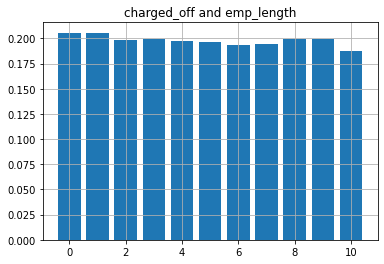

In [36]:
# Relation of charged_off and emp_length
plt.bar(x=charged_off_emp_length.index, height=charged_off_emp_length.values)
plt.title('charged_off and emp_length')
plt.grid()
plt.show()

**Not much vary, so dropping 'emp_length' feature.**

In [37]:
dataset.drop(labels=['emp_length'], axis=1, inplace=True)

In [38]:
dataset.shape

(1345310, 29)

### Feature - Subgrade ### 

In [39]:
# Check 'sub_grade' unique
dataset['sub_grade'].unique()

array(['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2',
       'A4', 'E3', 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5',
       'F2', 'E4', 'D2', 'E1', 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4',
       'F4', 'G5'], dtype=object)

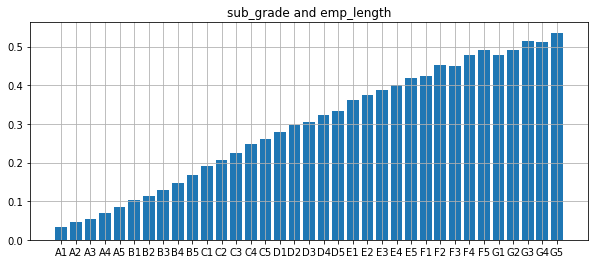

In [40]:
# Count 'sub_grade' by 'charged_off'=1
charged_off_sub_grade = dataset.groupby('sub_grade')['charged_off'].value_counts(normalize=True).loc[:,1]

# Relation of sub_grade and emp_length
fig = plt.figure(figsize=(10,4))
plt.bar(x=charged_off_sub_grade.index, height=charged_off_sub_grade.values)

plt.title ('sub_grade and emp_length')
plt.grid()
plt.show()

**There is a clear trend between sub_grade and emp_length**

In [41]:
# The month the borrower’s earliest reported credit line was opened
dataset['earliest_cr_line'].unique()
dataset['earliest_cr_line'] = dataset['earliest_cr_line'].apply(lambda s: int(s[-4:]))

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


### 4.2. Continuous features ###

### Feature - Annual Income ###

         annual_inc
count  1.345310e+06
mean   7.624764e+04
std    6.992510e+04
min    0.000000e+00
25%    4.578000e+04
50%    6.500000e+04
75%    9.000000e+04
max    1.099920e+07


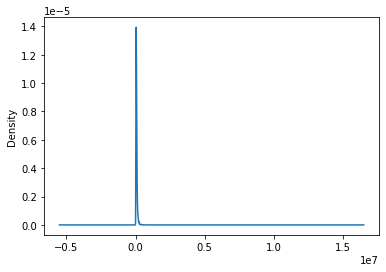

In [42]:
print(dataset[['annual_inc']].describe())

dataset['annual_inc'].plot.density()
plt.show()

It has large range from: 0 to 10,999,200 with Mean =  76,247. Median = 65,000.

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


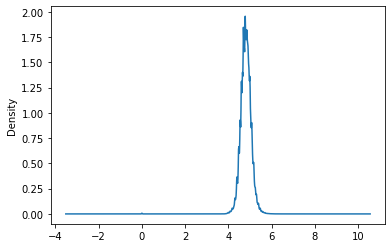

In [43]:
# Take a log transform 'annual_inc'
dataset['log_annual_inc'] = dataset['annual_inc'].apply(lambda x:np.log10(1+x))

dataset['log_annual_inc'].plot.density()
plt.show()

In [44]:
dataset.drop(labels=['annual_inc'], axis=1, inplace=True)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


### Feature - FICO Scores ###

In [45]:
print(dataset['fico_range_low'].unique())
print(dataset['fico_range_high'].unique())
print()

[675. 715. 695. 690. 680. 705. 685. 700. 665. 720. 745. 800. 725. 835.
 780. 660. 730. 750. 670. 710. 755. 795. 775. 785. 740. 770. 765. 735.
 790. 815. 845. 760. 805. 810. 825. 820. 840. 830. 630. 625.]
[679. 719. 699. 694. 684. 709. 689. 704. 669. 724. 749. 804. 729. 839.
 784. 664. 734. 754. 674. 714. 759. 799. 779. 789. 744. 774. 769. 739.
 794. 819. 850. 764. 809. 814. 829. 824. 844. 834. 634. 629.]



In [46]:
# CORRELATION of 'fico_range_low' and'fico_range_high'
dataset[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


**Correlation high so keep 1 feature which averges of 2 FICO features**

In [47]:
dataset['fico_score'] = 0.5*dataset['fico_range_low'] + 0.5*dataset['fico_range_high']
dataset.drop(labels=['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


### 4.3 Encoding Categorical Data ###

In [48]:
# Take categorical columns
categorical_feature_mask = dataset.dtypes==object
categorical_cols = dataset.columns[categorical_feature_mask].tolist()
categorical_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [49]:
# Apply LabelEncoders
dataset[categorical_cols] = dataset[categorical_cols].apply(lambda cols: LabelEncoder().fit_transform(cols))
dataset[categorical_cols][:3]

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,2,13,1,0,2,38,1,0
1,2,10,1,0,11,41,1,0
2,1,8,1,0,4,14,1,1


In [50]:
dataset.columns

Index(['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'home_ownership', 'verification_status', 'purpose',
       'addr_state', 'dti', 'earliest_cr_line', 'revol_util',
       'initial_list_status', 'last_pymnt_amnt', 'application_type',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc',
       'num_actv_rev_tl', 'charged_off', 'log_annual_inc', 'fico_score'],
      dtype='object')

### 4.4. Sampling Data ### 

In [51]:
dataset['charged_off'].value_counts()

0    1076751
1     268559
Name: charged_off, dtype: int64

In [52]:
# Set number of sampling
n_sampling = 10000

loanstatus_0 = dataset[dataset["charged_off"]==0]
loanstatus_1 = dataset[dataset["charged_off"]==1]

subset_loanstatus_0 = loanstatus_0.sample(n=n_sampling, random_state=42)
subset_loanstatus_1 = loanstatus_1.sample(n=n_sampling, random_state=42)

print('subset_loanstatus_0:', subset_loanstatus_0.shape)
print('subset_loanstatus_1:', subset_loanstatus_1.shape)

subset_loanstatus_0: (10000, 28)
subset_loanstatus_1: (10000, 28)


In [53]:
# New balanced dataset
dataset_sampling = pd.concat([subset_loanstatus_1, subset_loanstatus_0])

# Shuffle balanced dataset
dataset_sampling = dataset_sampling.sample(frac=1, random_state=42).reset_index(drop=True)

print ('dataset_sampling shape:', dataset_sampling.shape)
dataset_sampling[:3]

dataset_sampling shape: (20000, 28)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,dti,earliest_cr_line,revol_util,initial_list_status,last_pymnt_amnt,application_type,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,12000.0,12000.0,60,16.29,293.67,3,16,1,0,2,3,36.35,1993,63.4,0,10727.74,0,9.0,13233.0,3432.0,83.7,260.0,7.0,4.0,9.0,0,4.748196,687.0
1,13850.0,13850.0,36,16.59,490.97,3,16,1,0,4,18,17.03,2006,36.0,0,490.97,0,13.0,2122.0,2614.0,42.0,45.0,3.0,0.0,11.0,1,4.792399,687.0
2,35000.0,35000.0,36,12.99,1179.12,2,11,1,2,2,31,22.32,1989,36.6,1,1179.12,1,5.0,15228.0,7675.0,41.9,316.0,3.0,4.0,8.0,1,4.776745,682.0


In [54]:
dataset_sampling['charged_off'].value_counts()

0    10000
1    10000
Name: charged_off, dtype: int64

In [55]:
# Apply Mean of column to Na 
dataset_sampling.fillna(dataset_sampling.mean(),inplace = True)

## 5. Modeling ## 

### 5.1. Train Test Split ### 

In [56]:
Y = dataset_sampling['charged_off']
X = dataset_sampling.loc[:, dataset_sampling.columns != 'charged_off']

In [57]:
# Split dataset 0.8-0.2 ratio
validation_size = 0.2 
seed=7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [58]:
print('X_train shape:',X_train.shape)
print('X_test shape:',X_test.shape)

X_train shape: (16000, 27)
X_test shape: (4000, 27)


### 5.3. Compare Models and Algorithms ### 

In [59]:
# Set hyperparams
num_folds = 10
seed = 7
scoring = 'roc_auc' 
# (how much the model is capable of distinguishing between classes)

### MODELS ###

In [60]:
# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
# Neural Network
models.append(('NN', MLPClassifier()))
# Ensable Models 
# -- Boosting methods
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
# -- Bagging methods
models.append(('RF', RandomForestClassifier()))
models.append(('ET', ExtraTreesClassifier()))

### K-FOLD CROSS VALIDATION ###

In [61]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = (name, cv_results.mean(), cv_results.std())
    print(msg)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


('LR', 0.9030446888995785, 0.008955047303018722)
('LDA', 0.9036162494842171, 0.005050278627792533)
('KNN', 0.8484942390527245, 0.00913103835062616)
('CART', 0.8232709861947324, 0.006094564169583559)
('NN', 0.8958117916618058, 0.014438862576691604)
('AB', 0.9369477652835057, 0.006462106393384933)
('GBM', 0.9461221572151975, 0.006440170214051855)
('RF', 0.940365375828914, 0.005866959606048562)
('ET', 0.9311517253023686, 0.005637693940008024)


### ALGORITHM COMPARISON ###

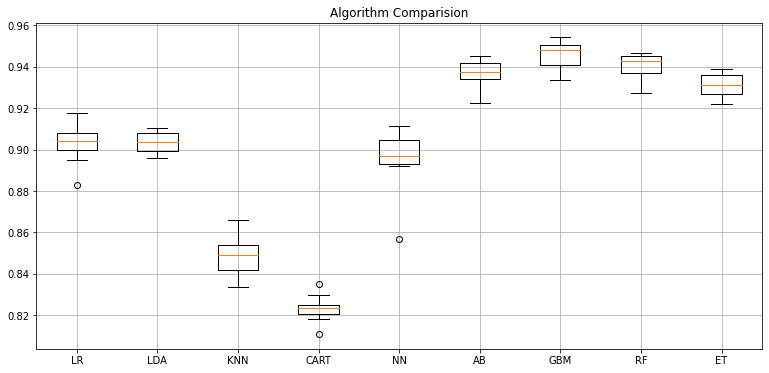

In [62]:
fig = plt.figure(figsize=(13,6))
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.title('Algorithm Comparision')
plt.grid()
plt.show()

***From the result above, choose GBM it for grid research**

## 6. Model Tuning and Grid Search ## 

In [63]:
# Grid Search
n_estimators = [20,180, 250]
max_depth = [2, 3, 5]

param_grid = dict(n_estimators=n_estimators, max_depth=max_depth)
model = GradientBoostingClassifier()
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)

In [64]:
# Results
print('Best: %f a and %s' % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
ranks = grid_result.cv_results_['rank_test_score']

for mean, std, param, rank in zip(means, stds, params, ranks):
    print("#%d %f (%f) with: %r" % (rank, mean, std, param))

Best: 0.948784 a and {'max_depth': 3, 'n_estimators': 250}
#9 0.925301 (0.006418) with: {'max_depth': 2, 'n_estimators': 20}
#6 0.945461 (0.005948) with: {'max_depth': 2, 'n_estimators': 180}
#5 0.946042 (0.006171) with: {'max_depth': 2, 'n_estimators': 250}
#8 0.935614 (0.006792) with: {'max_depth': 3, 'n_estimators': 20}
#4 0.947892 (0.006326) with: {'max_depth': 3, 'n_estimators': 180}
#1 0.948784 (0.006097) with: {'max_depth': 3, 'n_estimators': 250}
#7 0.942120 (0.005514) with: {'max_depth': 5, 'n_estimators': 20}
#2 0.948653 (0.005353) with: {'max_depth': 5, 'n_estimators': 180}
#3 0.948538 (0.005159) with: {'max_depth': 5, 'n_estimators': 250}


In [65]:
# Take params
params_max_depth = grid_result.best_params_['max_depth']
params_n_estimators = grid_result.best_params_['n_estimators']

## 7. Finalise the Model ##

### 7.1. Check on TEST dataset ###

In [66]:
# Prepare model
model = GradientBoostingClassifier(max_depth=params_max_depth, n_estimators=params_n_estimators)
model.fit(X_train, Y_train)

GradientBoostingClassifier(n_estimators=250)

In [67]:
# Accuracy on TEST dataset
predictions = model.predict(X_test)
print('ACCURACY_SCORE on TEST set:', accuracy_score(Y_test, predictions))
print(confusion_matrix(Y_test, predictions))
print(classification_report(Y_test, predictions))

ACCURACY_SCORE on TEST set: 0.8775
[[1640  357]
 [ 133 1870]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1997
           1       0.84      0.93      0.88      2003

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



<AxesSubplot:xlabel='Predicted', ylabel='Actual'>

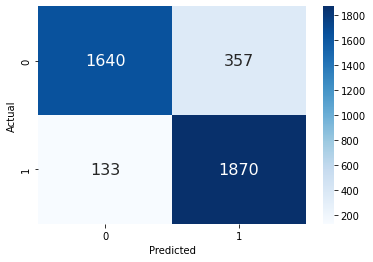

In [68]:
# Heatmap
df_cm = pd.DataFrame(confusion_matrix(Y_test, predictions), columns=np.unique(Y_test),\
                     index = np.unique(Y_test))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", fmt='.4g', annot=True,annot_kws={"size": 16})# font size

***The model is quite good.***

### 7.2. Feature Importance ###

In [69]:
model.feature_importances_

array([1.89882440e-03, 4.91494607e-03, 4.42569628e-02, 1.39923283e-02,
       3.16230622e-02, 1.58332330e-03, 5.39448088e-02, 5.16867734e-04,
       8.22176523e-04, 1.73084191e-03, 1.51060647e-03, 3.23004260e-03,
       2.89390377e-03, 1.91474715e-03, 1.84530616e-03, 8.01145881e-01,
       1.43980313e-04, 1.31960644e-02, 3.24397551e-03, 2.18632710e-03,
       1.96152439e-03, 3.49709547e-03, 1.58901331e-03, 7.40880688e-04,
       6.65700892e-04, 3.06756899e-03, 1.88323947e-03])

[1.89882440e-03 4.91494607e-03 4.42569628e-02 1.39923283e-02
 3.16230622e-02 1.58332330e-03 5.39448088e-02 5.16867734e-04
 8.22176523e-04 1.73084191e-03 1.51060647e-03 3.23004260e-03
 2.89390377e-03 1.91474715e-03 1.84530616e-03 8.01145881e-01
 1.43980313e-04 1.31960644e-02 3.24397551e-03 2.18632710e-03
 1.96152439e-03 3.49709547e-03 1.58901331e-03 7.40880688e-04
 6.65700892e-04 3.06756899e-03 1.88323947e-03]


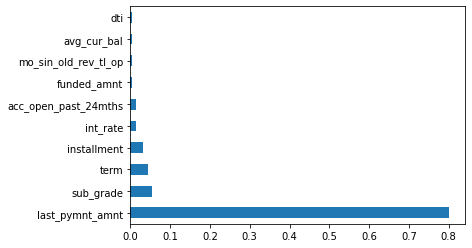

In [70]:
print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

 GBM model helps to show the most important feature for this prediction is: 'last_pymnt_amnt'